# NF-ToN-IoT — Tree Models: Black-Box Attacks + ESI

Third dataset for the LNCS extension. Evaluates RF and XGBoost only
(MLP is already evaluated on Phishing/UNSW in the base study).

Parquet is read in streaming batches so the full 1.16M-row file is
never held in memory simultaneously — peak RAM stays under ~150 MB.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap, warnings
import pyarrow
import pyarrow.parquet as pq
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
import xgboost as xgb

sns.set(style="whitegrid")
EPSILONS   = np.linspace(0, 0.3, 10)
N_ATTACK   = 300
N_HSJ      = 120
TARGET_PER_CLASS = 20_000   # 40K total — well within MacBook RAM

print(f"xgb {xgb.__version__}  shap {shap.__version__}  pyarrow {pyarrow.__version__}")

xgb 3.3.0  shap 0.52.0  pyarrow 24.0.0


In [4]:
# Stream the parquet in 50K-row batches — never load the full file into RAM
pf = pq.ParquetFile("NF-ToN-IoT.parquet")
FEAT_COLS = [c for c in pf.schema_arrow.names if c not in ("Label", "Attack")]

benign, attack = [], []
n_b, n_a = 0, 0

for batch in pf.iter_batches(batch_size=50_000):
    df_b = batch.to_pandas()
    if n_b < TARGET_PER_CLASS:
        b = df_b[df_b["Label"] == 0]
        take = min(len(b), TARGET_PER_CLASS - n_b)
        if take > 0:
            benign.append(b.sample(take, random_state=42))
            n_b += take
    if n_a < TARGET_PER_CLASS:
        a = df_b[df_b["Label"] == 1]
        take = min(len(a), TARGET_PER_CLASS - n_a)
        if take > 0:
            attack.append(a.sample(take, random_state=42))
            n_a += take
    del df_b
    if n_b >= TARGET_PER_CLASS and n_a >= TARGET_PER_CLASS:
        break

del pf
df_s = pd.concat(benign + attack).reset_index(drop=True)
del benign, attack

X = df_s[FEAT_COLS].values.astype(np.float32)
y = df_s["Label"].values.astype(int)
del df_s

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2,
                                            random_state=42, stratify=y)
sc = StandardScaler().fit(X_tr)
X_tr, X_te = sc.transform(X_tr), sc.transform(X_te)

print(f"Loaded  benign={n_b}  attack={n_a}  total={n_b+n_a}")
print(f"Train {X_tr.shape}  Test {X_te.shape}")
print(f"Features ({len(FEAT_COLS)}): {FEAT_COLS}")


Loaded  benign=20000  attack=20000  total=40000
Train (32000, 10)  Test (8000, 10)
Features (10): ['L4_SRC_PORT', 'L4_DST_PORT', 'PROTOCOL', 'L7_PROTO', 'IN_BYTES', 'OUT_BYTES', 'IN_PKTS', 'OUT_PKTS', 'TCP_FLAGS', 'FLOW_DURATION_MILLISECONDS']


In [5]:
print("Training RF (100 trees, depth 8)...")
rf = RandomForestClassifier(n_estimators=100, max_depth=8,
                             n_jobs=-1, random_state=42).fit(X_tr, y_tr)
print(f"  RF  clean acc: {rf.score(X_te, y_te):.4f}")

print("Training XGBoost (100 trees, depth 5)...")
xgb_m = xgb.XGBClassifier(n_estimators=100, max_depth=5,
    learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
    eval_metric="logloss", random_state=42, verbosity=0).fit(X_tr, y_tr)
print(f"  XGB clean acc: {xgb_m.score(X_te, y_te):.4f}")


Training RF (100 trees, depth 8)...
  RF  clean acc: 0.9976
Training XGBoost (100 trees, depth 5)...
  XGB clean acc: 0.9976


In [6]:
# Black-box attack helpers
def _xent(pp, y):
    return -np.log(np.clip(pp[np.arange(len(y)), y], 1e-10, 1.0))

def zoo_fgsm(pp, X, y, eps, delta=1e-3):
    base = _xent(pp(X), y)
    g = np.zeros_like(X)
    for j in range(X.shape[1]):
        Xp = X.copy(); Xp[:, j] += delta
        g[:, j] = (_xent(pp(Xp), y) - base) / delta
    return X + eps * np.sign(g)

def square_attack(pp, X, y, eps, n_queries=150, p_init=0.5, seed=0):
    rng = np.random.RandomState(seed)
    n, d = X.shape
    Xa = np.clip(X + rng.choice([-eps, eps], size=X.shape), X-eps, X+eps)
    best = _xent(pp(Xa), y)
    for q in range(1, n_queries + 1):
        k = max(1, int(max(p_init*(1-q/n_queries)**2, 1/d) * d))
        Xn = Xa.copy()
        for i in range(n):
            idx = rng.choice(d, size=k, replace=False)
            Xn[i, idx] = X[i, idx] + rng.choice([-eps, eps], size=k)
        Xn = np.clip(Xn, X-eps, X+eps)
        nl = _xent(pp(Xn), y); m = nl > best
        Xa[m] = Xn[m]; best[m] = nl[m]
    return Xa

def hopskipjump(pr, X, y, eps, max_iter=8, n_grad=20, seed=0):
    rng = np.random.RandomState(seed)
    def _bs(x0, x1, y0, steps=12):
        lo, hi = x0.copy(), x1.copy()
        for _ in range(steps):
            mid = (lo + hi) / 2
            if pr(mid.reshape(1, -1))[0] != y0: hi = mid
            else: lo = mid
        return hi
    n, d = X.shape; Xa = X.copy()
    for i in range(n):
        x0, y0 = X[i], y[i]; xadv = None
        for sc in [1.0, 2.0, 4.0]:
            c = np.clip(x0 + rng.uniform(-sc*eps, sc*eps, d), x0-eps, x0+eps)
            if pr(c.reshape(1, -1))[0] != y0: xadv = c; break
        if xadv is None: continue
        xb = _bs(x0, xadv, y0)
        for t in range(max_iter):
            U = rng.randn(n_grad, d)
            U /= np.linalg.norm(U, axis=1, keepdims=True) + 1e-10
            probes = np.clip(xb + 1e-3*U, x0-eps, x0+eps)
            gv = (U * (pr(probes) != y0).astype(float).reshape(-1, 1)).mean(0)
            nm = np.linalg.norm(gv)
            if nm > 1e-10: gv /= nm
            xn = np.clip(xb + eps/np.sqrt(t+1)*gv, x0-eps, x0+eps)
            if pr(xn.reshape(1, -1))[0] != y0:
                xb = _bs(x0, xn, y0, steps=8)
        Xa[i] = xb
    return Xa

print("Attack functions ready.")


Attack functions ready.


In [7]:
def eval_attacks(model, label):
    pp = model.predict_proba; pr = model.predict
    ia = resample(np.arange(len(X_te)), n_samples=N_ATTACK,
                  stratify=y_te, random_state=42)
    ih = resample(np.arange(len(X_te)), n_samples=N_HSJ,
                  stratify=y_te, random_state=42)
    Xa, ya = X_te[ia], y_te[ia]
    Xh, yh = X_te[ih], y_te[ih]
    res = {k: [] for k in ["zoo_fgsm", "square", "hsj"]}
    print(f"\n=== {label} ===")
    for eps in EPSILONS:
        Xzf = zoo_fgsm(pp, Xa, ya, eps)
        Xsq = square_attack(pp, Xa, ya, eps)
        Xhj = hopskipjump(pr, Xh, yh, eps)
        res["zoo_fgsm"].append((pr(Xzf) == ya).mean())
        res["square"].append((pr(Xsq) == ya).mean())
        res["hsj"].append((pr(Xhj) == yh).mean())
        print(f"  eps={eps:.2f}  ZOO={res['zoo_fgsm'][-1]:.3f}"
              f"  SQ={res['square'][-1]:.3f}  HSJ={res['hsj'][-1]:.3f}")
    ri = {k: round(np.trapezoid(v, EPSILONS) / (EPSILONS[-1] - EPSILONS[0]), 3)
          for k, v in res.items()}
    print(f"  RI => {ri}")
    res["RI"] = ri; res["label"] = label
    res["clean"] = model.score(Xa, ya)
    return res

res_rf  = eval_attacks(rf,    "ToN-IoT / RF")
res_xgb = eval_attacks(xgb_m, "ToN-IoT / XGB")



=== ToN-IoT / RF ===


Task was destroyed but it is pending!
task: <Task pending name='Task-163' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/vkhawarey/Documents/git/moviecruncher/dataviz/robustness_drift_classifiers/.venv/lib/python3.14/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-164' coro=<Kernel.shell_main() running at /Users/vkhawarey/Documents/git/moviecruncher/dataviz/robustness_drift_classifiers/.venv/lib/python3.14/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/vkhawarey/Documents/git/moviecruncher/dataviz/robustness_drift_classifiers/.venv/lib/python3.14/site-packages/zmq/eventloop/zmqstream.py:563]>
Task was destroyed but it is pending!
task: <Task pending name='Task-164' coro=<Kernel.shell_main() running at /Users/vkhawarey/Documents/git/moviecruncher/dataviz/robustness_drift_classifiers/.venv/lib/python3.14/site-packages/ipykernel/kernelbase.py:597> cb=[Task.tas

  eps=0.00  ZOO=1.000  SQ=1.000  HSJ=1.000
  eps=0.03  ZOO=0.930  SQ=0.457  HSJ=0.508
  eps=0.07  ZOO=0.503  SQ=0.453  HSJ=0.467
  eps=0.10  ZOO=0.530  SQ=0.450  HSJ=0.475
  eps=0.13  ZOO=0.527  SQ=0.450  HSJ=0.475
  eps=0.17  ZOO=0.703  SQ=0.450  HSJ=0.492
  eps=0.20  ZOO=0.540  SQ=0.450  HSJ=0.492
  eps=0.23  ZOO=0.747  SQ=0.450  HSJ=0.492
  eps=0.27  ZOO=0.743  SQ=0.450  HSJ=0.500
  eps=0.30  ZOO=0.777  SQ=0.450  HSJ=0.500
  RI => {'zoo_fgsm': np.float64(0.679), 'square': np.float64(0.482), 'hsj': np.float64(0.517)}

=== ToN-IoT / XGB ===
  eps=0.00  ZOO=1.000  SQ=1.000  HSJ=1.000
  eps=0.03  ZOO=0.967  SQ=0.453  HSJ=0.475
  eps=0.07  ZOO=0.973  SQ=0.410  HSJ=0.500
  eps=0.10  ZOO=0.970  SQ=0.433  HSJ=0.467
  eps=0.13  ZOO=0.973  SQ=0.430  HSJ=0.492
  eps=0.17  ZOO=0.973  SQ=0.430  HSJ=0.492
  eps=0.20  ZOO=0.973  SQ=0.430  HSJ=0.492
  eps=0.23  ZOO=0.973  SQ=0.427  HSJ=0.492
  eps=0.27  ZOO=0.973  SQ=0.420  HSJ=0.492
  eps=0.30  ZOO=0.967  SQ=0.417  HSJ=0.492
  RI => {'zoo_fgsm': n

In [8]:
# TreeSHAP + ESI (256-sample subset — fast and statistically sufficient)
def _sv1(sv):
    if isinstance(sv, list): return sv[1]
    return sv[:, :, 1] if sv.ndim == 3 else sv

idx_s = resample(np.arange(len(X_te)), n_samples=256,
                 stratify=y_te, random_state=42)
Xs, ys = X_te[idx_s], y_te[idx_s]

def esi_for(model, label):
    exp = shap.TreeExplainer(model)
    base = _sv1(exp.shap_values(Xs))
    drifts = []
    for eps in EPSILONS:
        Xadv = zoo_fgsm(model.predict_proba, Xs, ys, eps)
        adv  = _sv1(exp.shap_values(Xadv))
        drifts.append(np.abs(adv - base).mean())
    drifts = np.array(drifts)
    D_max = drifts[-1] if drifts[-1] > 0 else 1.0
    esi = round(float(1 - np.trapezoid(drifts / D_max, EPSILONS)
                      / (EPSILONS[-1] - EPSILONS[0])), 3)
    print(f"  {label}: ESI={esi}")
    return esi, drifts

print("Computing TreeSHAP + ESI...")
esi_rf,  drift_rf  = esi_for(rf,    "RF")
esi_xgb, drift_xgb = esi_for(xgb_m, "XGB")


Computing TreeSHAP + ESI...
  RF: ESI=0.214
  XGB: ESI=0.159


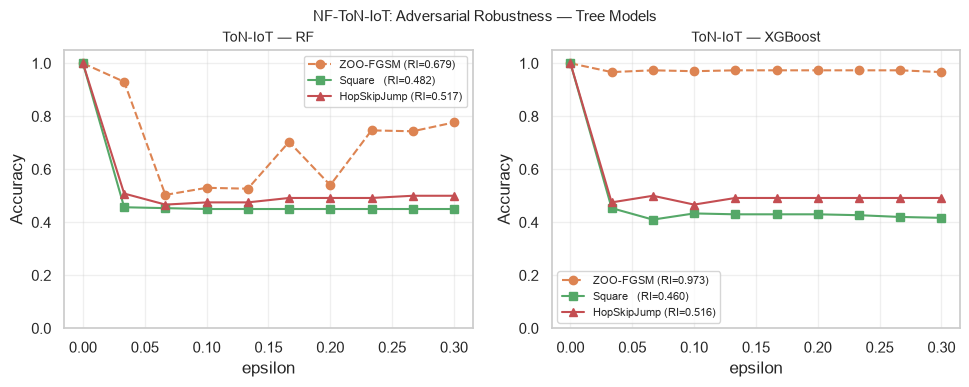

Saved: toniot_robustness_curves.png


In [9]:
# Robustness curves — 2-panel (RF / XGB)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, res, title in [(axes[0], res_rf, "ToN-IoT — RF"),
                        (axes[1], res_xgb, "ToN-IoT — XGBoost")]:
    ri_z = res["RI"]["zoo_fgsm"]
    ri_s = res["RI"]["square"]
    ri_h = res["RI"]["hsj"]
    ax.plot(EPSILONS, res["zoo_fgsm"], "o--", color="C1",
            label=f"ZOO-FGSM (RI={ri_z:.3f})")
    ax.plot(EPSILONS, res["square"],   "s-",  color="C2",
            label=f"Square   (RI={ri_s:.3f})")
    ax.plot(EPSILONS, res["hsj"],      "^-",  color="C3",
            label=f"HopSkipJump (RI={ri_h:.3f})")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("epsilon"); ax.set_ylabel("Accuracy")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_ylim(0, 1.05)

fig.suptitle("NF-ToN-IoT: Adversarial Robustness — Tree Models", fontsize=11)
fig.tight_layout(pad=1.5); fig.subplots_adjust(top=0.88)
plt.savefig("toniot_robustness_curves.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: toniot_robustness_curves.png")


In [10]:
# Master 3-dataset table
PRIOR = {
    "Phishing": {
        "MLP": {"clean":0.857,"RI_zoo":0.610,"RI_pgd":0.725,"RI_sq":"—","RI_hsj":"—","ESI":"—"},
        "RF":  {"clean":0.977,"RI_zoo":0.915,"RI_pgd":0.894,"RI_sq":0.793,"RI_hsj":0.805,"ESI":0.287},
        "XGB": {"clean":0.981,"RI_zoo":0.980,"RI_pgd":0.980,"RI_sq":0.362,"RI_hsj":0.653,"ESI":0.111},
    },
    "UNSW-NB15": {
        "MLP": {"clean":0.774,"RI_zoo":0.692,"RI_pgd":0.733,"RI_sq":"—","RI_hsj":"—","ESI":"—"},
        "RF":  {"clean":0.998,"RI_zoo":0.949,"RI_pgd":0.975,"RI_sq":0.502,"RI_hsj":0.875,"ESI":0.167},
        "XGB": {"clean":0.999,"RI_zoo":0.992,"RI_pgd":0.996,"RI_sq":0.636,"RI_hsj":0.715,"ESI":0.063},
    },
}

ri_rf = res_rf["RI"]; ri_xgb = res_xgb["RI"]
PRIOR["NF-ToN-IoT"] = {
    "MLP": {"clean":"—","RI_zoo":"—","RI_pgd":"—","RI_sq":"—","RI_hsj":"—","ESI":"—"},
    "RF":  {"clean":round(res_rf["clean"],3), "RI_zoo":ri_rf["zoo_fgsm"],  "RI_pgd":"—",
            "RI_sq":ri_rf["square"],  "RI_hsj":ri_rf["hsj"],  "ESI":esi_rf},
    "XGB": {"clean":round(res_xgb["clean"],3),"RI_zoo":ri_xgb["zoo_fgsm"],"RI_pgd":"—",
            "RI_sq":ri_xgb["square"],"RI_hsj":ri_xgb["hsj"],"ESI":esi_xgb},
}

rows = []
for ds in ["Phishing", "UNSW-NB15", "NF-ToN-IoT"]:
    for m in ["MLP", "RF", "XGB"]:
        d = PRIOR[ds][m]
        rows.append([ds, m, d["clean"], d["RI_zoo"], d["RI_pgd"],
                     d["RI_sq"], d["RI_hsj"], d["ESI"]])

master = pd.DataFrame(rows, columns=[
    "Dataset","Model","Clean Acc",
    "RI ZOO/FGSM","RI PGD","RI Square","RI HSJ","ESI"])
print("\n=== MASTER 3-DATASET TABLE ===")
print(master.to_string(index=False))
master.to_csv("master_robustness_table.csv", index=False)
print("\nSaved: master_robustness_table.csv")



=== MASTER 3-DATASET TABLE ===
   Dataset Model Clean Acc RI ZOO/FGSM RI PGD RI Square RI HSJ    ESI
  Phishing   MLP     0.857        0.61  0.725         —      —      —
  Phishing    RF     0.977       0.915  0.894     0.793  0.805  0.287
  Phishing   XGB     0.981        0.98   0.98     0.362  0.653  0.111
 UNSW-NB15   MLP     0.774       0.692  0.733         —      —      —
 UNSW-NB15    RF     0.998       0.949  0.975     0.502  0.875  0.167
 UNSW-NB15   XGB     0.999       0.992  0.996     0.636  0.715  0.063
NF-ToN-IoT   MLP         —           —      —         —      —      —
NF-ToN-IoT    RF       1.0       0.679      —     0.482  0.517  0.214
NF-ToN-IoT   XGB       1.0       0.973      —      0.46  0.516  0.159

Saved: master_robustness_table.csv


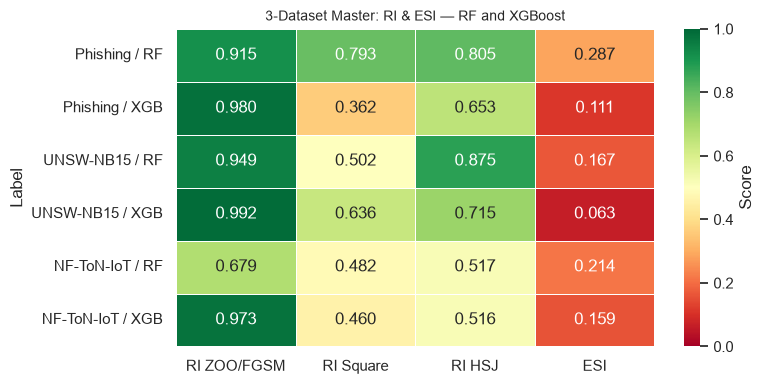

Saved: master_heatmap.png


In [11]:
# Heatmap — tree models only (MLP rows skipped since no black-box RI)
numeric_cols = ["RI ZOO/FGSM", "RI Square", "RI HSJ", "ESI"]
m_tree = master[master["Model"] != "MLP"].copy()
for c in numeric_cols:
    m_tree[c] = pd.to_numeric(m_tree[c], errors="coerce")
m_tree["Label"] = m_tree["Dataset"] + " / " + m_tree["Model"]
pivot = m_tree.set_index("Label")[numeric_cols]

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot.astype(float), annot=True, fmt=".3f",
            cmap="RdYlGn", vmin=0.0, vmax=1.0, ax=ax,
            cbar_kws={"label": "Score"},
            linewidths=0.5, linecolor="white")
ax.set_title("3-Dataset Master: RI & ESI — RF and XGBoost", fontsize=10)
plt.tight_layout()
plt.savefig("master_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: master_heatmap.png")
